### Setup (Optional)

**What this cell does:** Shows optional commands to clone the course repository and install required packages.

**What we learn/functionality:** How to prepare the environment when running the notebook on a fresh machine (for example, Colab).

In [ ]:
# Optional setup commands for fresh environments (keep commented in local runs).
# !git clone https://github.com/recepgul82/music-digital-methods.git
# !pip install -r music-digital-methods/setup/requirements.txt

**The cell below is only for logistics. Just run it and disregard**

### Project Path Setup

**What this cell does:** Detects the repository root dynamically, prints it, and adds it to `sys.path` so local modules can be imported.

**What we learn/functionality:** How to make notebooks portable across different folder structures without hardcoding absolute paths.

In [ ]:
# Import utilities for dynamic path detection and Python module path updates.
import sys
from pathlib import Path


def find_repo_root(marker_dir="course_code"):
    # Search upward from the current working directory first.
    p = Path.cwd().resolve()
    for _ in range(10):
        if (p / marker_dir).is_dir():
            return p
        if p == p.parent:
            break
        p = p.parent

    # Fallback: scan common roots (e.g., Colab /content) for the marker directory.
    for base in [Path("/content"), Path.cwd().resolve()]:
        if base.exists():
            for candidate in base.rglob(marker_dir):
                if candidate.is_dir():
                    return candidate.parent

    raise RuntimeError(f"Could not locate repo root containing '{marker_dir}/'.")


# Resolve repository root and make local package imports available.
REPO_ROOT = find_repo_root("course_code")
print("REPO_ROOT =", REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))



1. Load Data

### Load and Merge Lyrics Data

**What this cell does:** Reads all artist CSV files, concatenates them into one DataFrame, drops missing lyrics, and normalizes column names.

**What we learn/functionality:** How to build a clean unified dataset from multiple files for text analysis.

In [ ]:
# Load all per-artist CSV lyric files and combine into a single analysis table.
import pandas as pd
from pathlib import Path

# Folder containing lyric CSV files.
data_path = REPO_ROOT / "data/song_lyrics/csv"

dfs = []
for file in data_path.glob("*.csv"):
    # Read each artist file; first column is an index column in these files.
    df = pd.read_csv(file, index_col=0)
    dfs.append(df)

# Merge all files into one DataFrame and clean key fields.
lyrics_df = pd.concat(dfs, ignore_index=True)
lyrics_df = lyrics_df.dropna(subset=["Lyric"])
lyrics_df.columns = lyrics_df.columns.str.lower()  # Normalize to lowercase column names.
lyrics_df.head()



2. Simple EDA

### Artist Distribution Check

**What this cell does:** Counts songs per artist and returns the total number of records.

**What we learn/functionality:** A quick quality check for class balance and dataset size.

In [ ]:
# Count how many songs each artist has and the total number of rows.
lyrics_df["artist"].value_counts(), lyrics_df["artist"].value_counts().sum()



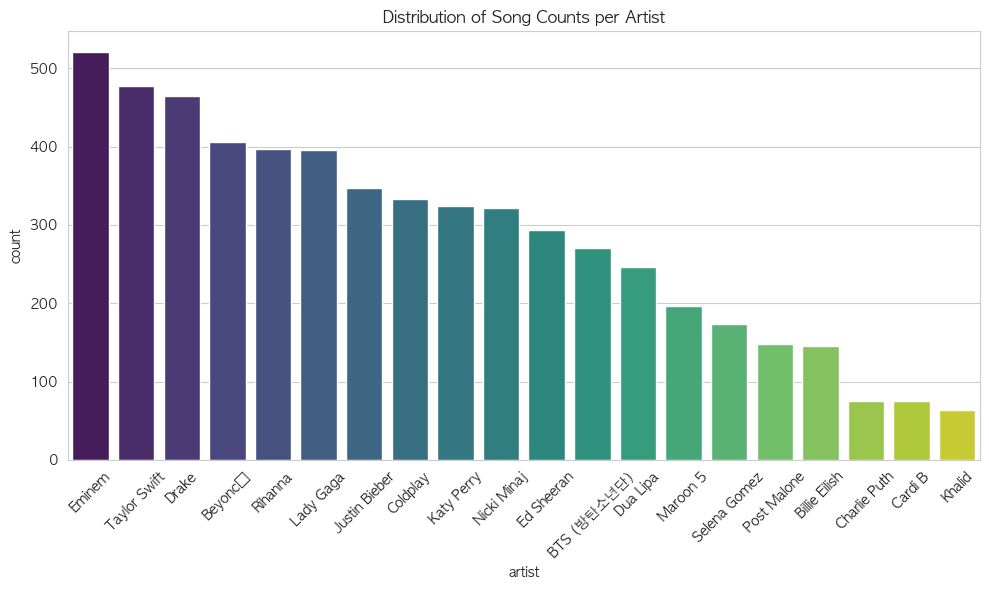

In [15]:
import warnings

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message="Glyph"
)
import seaborn as sns 
import matplotlib.pyplot as plt




#TODO: visualize the distribution of song counts per artist using a bar plot.
sns.set_style("whitegrid") # Set a clean style for better aesthetics
plt.figure(figsize=(10, 6)) # set figure size for better readability
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

order = lyrics_df['artist'].value_counts().index # sort artists by song count before plotting
palette = dict(
    zip(order, sns.color_palette("viridis", len(order)))
) # Create a color palette mapping each artist to a unique color

sns.countplot(x='artist', 
              data=lyrics_df, 
              order=order, 
              hue="artist", 
              palette=palette,
              legend=False
              )  
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability if there are many artists
plt.title('Distribution of Song Counts per Artist')

plt.tight_layout()

### Lyric Length Analysis

**What this cell does:** Computes lyric word counts and average lyric length by artist.

**What we learn/functionality:** How descriptive statistics reveal stylistic differences among artists.

In [ ]:
# Compute lyric length statistics (word count per song, then artist averages).
lyrics_df["lyric_length"] = lyrics_df["lyric"].str.split().str.len()

avg_length = (
    lyrics_df
    .groupby("artist")["lyric_length"]
    .mean()
    .sort_values(ascending=False)
)

avg_length



In [ ]:
# Create a scatter plot per artist for avg_length vs song count.
artist_counts = lyrics_df["artist"].value_counts()
artist_stats = pd.DataFrame({
    "artist": artist_counts.index,
    "song_count": artist_counts.values,
    "avg_length": avg_length[artist_counts.index].values
})  
sns.scatterplot(data=artist_stats, x="song_count", y="avg_length", hue="artist", palette=palette)
plt.title("Average Lyric Length vs Song Count per Artist")
plt.xlabel("Song Count")
plt.ylabel("Average Lyric Length (words)")
plt.legend(title="Artist", bbox_to_anchor=(1.05, 1), loc='upper left')  # Place legend outside the plot
plt.tight_layout()  

### Vocabulary Richness (TTR)

**What this cell does:** Calculates per-artist vocabulary size, total token count, and type-token ratio (TTR).

**What we learn/functionality:** How lexical diversity can be measured to compare writing style complexity.

In [ ]:
# Measure lexical richness per artist using vocabulary size and TTR.
artist_stats = lyrics_df.groupby("artist").agg(
    vocab_size=("lyric", lambda x: len(set(" ".join(x).split()))),
    total_tokens=("lyric", lambda x: len(" ".join(x).split())),
)

# Type-token ratio = unique words / total words.
artist_stats["ttr"] = artist_stats["vocab_size"] / artist_stats["total_tokens"]
artist_stats.sort_values("ttr", ascending=False)



In [ ]:
# visualize the relationship between vocabulary size and TTR across artists.
# use different shapes or colors for each artist to distinguish them in the scatter plot.
sns.scatterplot(
    data=artist_stats,
    x="vocab_size",
    y="ttr",
    hue=artist_stats.index,
    style=artist_stats.index,
    palette=palette
)

plt.title("Vocabulary Size vs Type-Token Ratio per Artist")
plt.xlabel("Vocabulary Size (unique words)")
plt.ylabel("Type-Token Ratio (TTR)")
plt.legend(title="Artist", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

3. Text Preprocessing

### Import Preprocessing Tools

**What this cell does:** Imports NLP tools for stopword removal, lemmatization, and regex-based cleaning.

**What we learn/functionality:** The core toolkit needed before text normalization.

In [ ]:
# Import NLP preprocessing libraries.
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re



### Download NLTK Resources

**What this cell does:** Downloads required NLTK corpora (`stopwords`, `wordnet`).

**What we learn/functionality:** Some NLP resources must be downloaded once before use.

In [ ]:
# Download required NLTK resources (run once per environment).
nltk.download("stopwords")
nltk.download("wordnet")



### Initialize Preprocessing Objects

**What this cell does:** Builds the English stopword set and initializes a WordNet lemmatizer.

**What we learn/functionality:** How reusable preprocessing components are prepared for pipeline functions.

In [ ]:
# Prepare reusable stopword set and lemmatizer objects.
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()



### Define Preprocessing Function

**What this cell does:** Defines a function that lowercases text, removes punctuation/non-letters, tokenizes, removes stopwords, and lemmatizes.

**What we learn/functionality:** How to compose a standard NLP cleaning pipeline in one reusable function.

In [ ]:
# Define a text-cleaning pipeline for lyrics.
def preprocess(text):
    # Lowercase for case-insensitive matching.
    text = text.lower()
    # Keep letters and whitespace only.
    text = re.sub(r"[^a-z\s]", "", text)
    # Tokenize by whitespace.
    tokens = text.split()
    # Remove common stopwords.
    tokens = [w for w in tokens if w not in stop_words]
    # Lemmatize tokens to base forms.
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return tokens



### Apply Preprocessing

**What this cell does:** Applies `preprocess` to each lyric and stores both tokenized and joined cleaned text versions.

**What we learn/functionality:** How to create both token-level and document-level representations for later models.

In [ ]:
# Apply preprocessing to each lyric and create token/text representations.
lyrics_df["clean_tokens"] = lyrics_df["lyric"].apply(preprocess)
lyrics_df["clean_text"] = lyrics_df["clean_tokens"].apply(lambda x: " ".join(x))



### Inspect Original vs Cleaned Text

**What this cell does:** Expands column display and shows one row with raw and cleaned text side by side.

**What we learn/functionality:** Visual validation of preprocessing quality before modeling.

In [ ]:
# Show one row to compare original and cleaned lyric text.
import pandas as pd
from IPython.display import display

# Avoid truncating long lyric text during display.
pd.set_option("display.max_colwidth", None)

display(lyrics_df[["artist", "title", "lyric", "clean_text"]].iloc[[0]])



### Inspect Token Output

**What this cell does:** Prints the first 40 cleaned tokens from the first lyric.

**What we learn/functionality:** A quick sanity check that tokenization and lemmatization behave as expected.

In [ ]:
# Print a token preview for quick preprocessing validation.
print("TOKENS AFTER PREPROCESSING:\n")
print(lyrics_df.iloc[0]["clean_tokens"][:40])



4. Bag-of-Words

### Build Bag-of-Words Matrix

**What this cell does:** Vectorizes cleaned lyrics into a term-frequency matrix and converts it to a DataFrame.

**What we learn/functionality:** How text is transformed into numeric features for analysis.

In [ ]:
# Build a Bag-of-Words representation from cleaned lyrics.
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(lyrics_df["clean_text"])

# Convert sparse matrix to a readable DataFrame (rows=songs, columns=terms).
bow_df = pd.DataFrame(
    X_bow.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=lyrics_df.index,
)

bow_df.head()



### View Non-Zero Terms for One Song

**What this cell does:** Displays only words that appear in the first lyric.

**What we learn/functionality:** How sparse BoW vectors map to real words in a single document.

In [ ]:
# Inspect non-zero BoW terms for the first song only.
bow_df.iloc[[0]].loc[:, bow_df.iloc[0] > 0]



### Global Frequent Words

**What this cell does:** Sums term counts across all songs and shows the most frequent words.

**What we learn/functionality:** How to identify dominant vocabulary in the full corpus.

In [ ]:
# Aggregate term counts across all songs and show top words.
word_counts = bow_df.sum(axis=0).sort_values(ascending=False)
print(bow_df.shape)
word_counts.head(20)



In [ ]:
# Visualize most common words as word cloud.
from wordcloud import WordCloud
# Generate a word cloud from the aggregated word counts.
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_counts)
# Display the generated word cloud.
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Song Lyrics")
plt.tight_layout()

### Artist-Specific Frequent Words

**What this cell does:** Filters BoW rows for one artist and computes their most common words.

**What we learn/functionality:** How to compare vocabulary usage at artist level.

In [ ]:
# Compute most frequent BoW terms for a selected artist.
artist = "Dua Lipa"
artist_bow = bow_df[lyrics_df["artist"] == artist]
artist_counts = artist_bow.sum(axis=0).sort_values(ascending=False)
artist_counts.head(15)



In [ ]:
wordcloud_artist = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(artist_counts)
# Display the generated word cloud.
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud_artist, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Song Lyrics for Dua Lipa")
plt.tight_layout()

5. Bigram Analysis

### Bigram Frequency Analysis

**What this cell does:** Builds a bigram vectorizer and lists the most frequent two-word phrases.

**What we learn/functionality:** How n-grams capture local phrase patterns beyond single words.

In [ ]:
# Build bigram counts to analyze common two-word phrases.
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))
X_bigram = bigram_vectorizer.fit_transform(lyrics_df["clean_text"])

bigram_counts = pd.DataFrame(
    X_bigram.sum(axis=0).A1,
    index=bigram_vectorizer.get_feature_names_out(),
    columns=["count"],
)

bigram_counts.sort_values("count", ascending=False).head(20)



In [ ]:
# Build a bigram word cloud to visualize common two-word phrases.
bigram_wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(bigram_counts["count"])
plt.figure(figsize=(15, 7.5))
plt.imshow(bigram_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Bigrams in Song Lyrics")
plt.tight_layout()

6. TF-IDF

### Compute TF-IDF Features

**What this cell does:** Creates a TF-IDF representation of cleaned lyrics.

**What we learn/functionality:** How to weight words by importance instead of raw frequency.

In [ ]:
# Build TF-IDF features to weight informative words higher than common words.
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(lyrics_df["clean_text"])

tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf.get_feature_names_out(),
)



# Analysis Tasks

## 1. Words that Describe Artists

### Average TF-IDF by Artist

**What this cell does:** Adds artist labels and averages TF-IDF scores per artist.

**What we learn/functionality:** How to derive representative term profiles for each artist.

In [ ]:
# Add artist labels and compute mean TF-IDF profile per artist.
tfidf_df["artist"] = lyrics_df["artist"].values
artist_tfidf = tfidf_df.groupby("artist").mean()


### Top TF-IDF Terms per Artist

**What this cell does:** Prints the top 5 highest-TF-IDF words for each artist profile.

**What we learn/functionality:** Which words are most characteristic for each artist.

In [ ]:
# Print top TF-IDF terms that characterize each artist.
for artist in artist_tfidf.index:
    print("\n", artist)
    print(artist_tfidf.loc[artist].sort_values(ascending=False).head(5))


In [ ]:
# Number of top TF-IDF terms to extract per artist
top_n = 5

# Create a set to store unique top terms across all artists
top_terms = set()

# For each artist, find the top TF-IDF terms and add them to the set
for artist in artist_tfidf.index:
    top_terms.update(
        artist_tfidf.loc[artist]              # Select TF-IDF vector for the artist
        .sort_values(ascending=False)         # Sort terms by TF-IDF score
        .head(top_n)                          # Take top N terms
        .index                                # Extract term names
    )

# Convert the set to a list so it can be used for indexing
top_terms = list(top_terms)

# Subset the TF-IDF matrix to include only the selected top terms
tfidf_top = artist_tfidf[top_terms]

# Create a figure for the heatmap
plt.figure(figsize=(12,6))

# Plot heatmap showing TF-IDF strength of selected terms for each artist
sns.heatmap(
    tfidf_top,
    cmap="viridis",      # Color map representing TF-IDF intensity
    annot=False,         # Do not display numeric values inside cells
    fmt=".2f"            # Formatting if annotations are enabled
)

# Add plot title and axis labels
plt.title("Top TF-IDF Terms Characterizing Each Artist")
plt.xlabel("Terms")
plt.ylabel("Artist")

# Adjust layout so labels and titles fit properly
plt.tight_layout()

## 2. Artist Similarity

### Build Artist-Level Documents

**What this cell does:** Concatenates all cleaned lyrics per artist into one document each.

**What we learn/functionality:** How to move from song-level to artist-level similarity analysis.

In [ ]:
# Concatenate all cleaned lyrics into one document per artist.
artist_docs = lyrics_df.groupby("artist")["clean_text"].apply(lambda x: " ".join(x))


### Vectorize Artist Documents

**What this cell does:** Fits TF-IDF on artist-level documents to produce an artist-feature matrix.

**What we learn/functionality:** How to represent each artist as a vector in shared term space.

In [ ]:
# Vectorize artist-level documents with TF-IDF.
tfidf_artist = TfidfVectorizer()
artist_matrix = tfidf_artist.fit_transform(artist_docs)



### Compute Artist Similarity

**What this cell does:** Computes cosine similarity between artist vectors and displays a similarity matrix.

**What we learn/functionality:** How numerically similar artists are based on lyrical language.

In [ ]:
# Compute cosine similarity between artist TF-IDF vectors.
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(artist_matrix)
sim_df = pd.DataFrame(sim, index=artist_docs.index, columns=artist_docs.index)
sim_df



In [ ]:
# Visualize artist similarity matrix as a heatmap.
plt.figure(figsize=(10, 8))
sns.heatmap(sim_df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Cosine Similarity Between Artists Based on TF-IDF Profiles")
plt.xlabel("Artist")
plt.ylabel("Artist")
plt.tight_layout()  

## 3. Distinctive Words per Artist

### Collect Distinctive Words

**What this cell does:** Stores top TF-IDF words for each artist in a dictionary.

**What we learn/functionality:** A reusable summary artifact for downstream interpretation or visualization.

In [ ]:
# Store top distinctive words per artist in a dictionary.
top_words = {}

for artist in artist_tfidf.index:
    top_words[artist] = (
        artist_tfidf.loc[artist]
        .sort_values(ascending=False)
        .head(15)
        .index
    )

top_words



In [ ]:
import math

artists = artist_tfidf.index
n = len(artists)

cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.flatten()

for i, artist in enumerate(artists):

    top_terms = (
        artist_tfidf.loc[artist]
        .sort_values(ascending=False)
        .head(10)
    )

    axes[i].barh(top_terms.index, top_terms.values)
    axes[i].invert_yaxis()
    axes[i].set_title(artist)
    axes[i].set_xlabel("TF-IDF")
    axes[i].set_xlim(0, 0.14)   # force same scale across all plots

# remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()